# Book Average Rating Prediction
### Machine Learning Project — Scikit-learn Only

---

**Dataset :** `books.csv` — 11,123 books scraped from Goodreads
**Target :** `average_rating` — predict the average reader rating of a book
**Approach :** Supervised regression using scikit-learn models only

---

## Project Pipeline

| Step | Section | Description |
|------|---------|-------------|
| 1 | Imports | Libraries and global settings |
| 2 | Data Loading | Load raw CSV, first look |
| 3 | **Data Cleaning** | Fix column names, handle zeros, parse dates, remove outliers |
| 4 | **EDA** | Visual exploration of the *cleaned* dataset |
| 5 | **Feature Engineering** | Build 19 informative features from raw columns |
| 6 | Preprocessing | sklearn Pipeline — imputation, scaling, encoding |
| 7 | Model Comparison | 14 sklearn models evaluated with 5-fold Cross-Validation |
| 8 | Hyperparameter Tuning | RandomizedSearchCV on the Top 3 models |
| 9 | Final Evaluation | Test-set metrics, residuals, feature importance |
| 10 | Summary | Consolidated results |

---

> **Note on order:** EDA is intentionally placed *after* cleaning so that every chart
> reflects the actual data the model will see — not corrupted zeros or unparsed strings.

## 1. Imports & Global Configuration

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re                          # regex for series-number extraction from titles
import warnings
warnings.filterwarnings("ignore")

# --- Statistical utilities ---------------------------------------------------
from scipy import stats            # QQ-plots, normality checks
from scipy.stats import randint, uniform  # distributions for RandomizedSearchCV

# --- Scikit-learn : model selection & evaluation ----------------------------
from sklearn.model_selection import (
    train_test_split,       # hold-out split
    cross_val_score,        # k-fold cross-validation
    KFold,                  # explicit fold strategy
    RandomizedSearchCV,     # hyperparameter search (faster than GridSearchCV)
)

# --- Scikit-learn : preprocessing -------------------------------------------
from sklearn.preprocessing import RobustScaler, OneHotEncoder
# RobustScaler  : uses median & IQR instead of mean & std → less sensitive to outliers
# OneHotEncoder : converts categorical columns into binary dummy variables

from sklearn.impute import SimpleImputer    # fill missing values (median / most_frequent)
from sklearn.pipeline import Pipeline       # chain preprocessing + model in one object
from sklearn.compose import ColumnTransformer  # apply different transforms per column type

# --- Scikit-learn : feature selection ----------------------------------------
from sklearn.feature_selection import mutual_info_regression
# Mutual Information measures non-linear statistical dependency (unlike Pearson r)

# --- Scikit-learn : linear models --------------------------------------------
from sklearn.linear_model import (
    LinearRegression,   # ordinary least squares baseline
    Ridge,              # L2 regularization — reduces overfitting
    Lasso,              # L1 regularization — also performs feature selection
    ElasticNet,         # mix of L1 + L2 (alpha controls ratio)
    HuberRegressor,     # robust to outliers in y (uses Huber loss)
)

# --- Scikit-learn : tree & ensemble models -----------------------------------
from sklearn.tree import DecisionTreeRegressor      # single tree, high variance
from sklearn.ensemble import (
    RandomForestRegressor,          # bagging of deep trees — variance reduction
    ExtraTreesRegressor,            # like RF but splits are fully random — faster
    GradientBoostingRegressor,      # sequential boosting with decision trees
    AdaBoostRegressor,              # adaptive boosting — weights hard examples
    BaggingRegressor,               # generic bagging wrapper
    HistGradientBoostingRegressor,  # histogram-based GBDT — fastest & most powerful in sklearn
)
from sklearn.svm import SVR             # support vector regression (RBF kernel)
from sklearn.neighbors import KNeighborsRegressor   # k-nearest neighbors

# --- Scikit-learn : metrics --------------------------------------------------
from sklearn.metrics import (
    mean_squared_error,              # MSE → take sqrt for RMSE
    mean_absolute_error,             # MAE — interpretable in original units
    r2_score,                        # coefficient of determination (0–1)
    mean_absolute_percentage_error,  # MAPE — percentage error
)

# --- Global settings ---------------------------------------------------------
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
RANDOM_STATE = 42      # ensures reproducibility across all random operations
np.random.seed(RANDOM_STATE)

DATASET_PATH = "books.csv"
TARGET_COL   = "average_rating"   # what we want to predict
CURRENT_YEAR = 2026               # used to compute book_age

print("All imports successful ✓")

All imports successful ✓


## 2. Data Loading & First Look

Before anything else we load the raw CSV and check its basic structure:
- **Shape** — how many rows and columns?
- **Column names** — are there any formatting issues?
- **Data types** — are numeric columns stored as numbers?
- **First rows** — do the values look plausible?

In [2]:
# Load the CSV; on_bad_lines="skip" silently drops any malformed rows
df_raw = pd.read_csv(DATASET_PATH, on_bad_lines="skip")

# The raw CSV ships with a leading-space bug in the column "  num_pages"
# strip() removes surrounding whitespace from ALL column names at once
df_raw.columns = df_raw.columns.str.strip()

print(f"Raw shape   : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"Columns     : {df_raw.columns.tolist()}")
df_raw.head()

Raw shape   : 11,123 rows × 12 columns
Columns     : ['bookID', 'title', 'authors', 'average_rating', 'isbn', 'isbn13', 'language_code', 'num_pages', 'ratings_count', 'text_reviews_count', 'publication_date', 'publisher']


,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,0439785960,9780439785969,eng,652,2095690,27591,9/16/2006,Scholastic Inc.
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,0439358078,9780439358071,eng,870,2153167,29221,9/1/2004,Scholastic Inc.
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,0439554896,9780439554893,eng,352,6333,244,11/1/2003,Scholastic
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9780439655484,eng,435,2339585,36325,5/1/2004,Scholastic Inc.
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,0439682584,9780439682589,eng,2690,41428,164,9/13/2004,Scholastic


In [3]:
# Data types tell us what preprocessing will be needed later:
#   - object  → needs parsing or encoding
#   - int64   → might need log-transform if skewed
#   - float64 → ready for modeling after scaling
print("=== Data Types ===")
print(df_raw.dtypes)
print()

# describe() gives min/max/quartiles for numeric columns
# Key things to look for: zeros in num_pages, zeros in average_rating
print("=== Statistical Summary ===")
df_raw.describe()

=== Data Types ===
bookID                  int64
title                  object
authors                object
average_rating        float64
isbn                   object
isbn13                  int64
language_code          object
num_pages               int64
ratings_count           int64
text_reviews_count      int64
publication_date       object
publisher              object
dtype: object

=== Statistical Summary ===


,bookID,average_rating,isbn13,num_pages,ratings_count,text_reviews_count
count,11123.000000,11123.000000,1.112300e+04,11123.000000,1.112300e+04,11123.000000
mean,21310.856963,3.934075,9.759880e+12,336.405556,1.794285e+04,542.048099
std,13094.727252,0.350485,4.429758e+11,241.152626,1.124992e+05,2576.619589
min,1.000000,0.000000,8.987060e+09,0.000000,0.000000e+00,0.000000
25%,10277.500000,3.770000,9.780345e+12,192.000000,1.040000e+02,9.000000
50%,20287.000000,3.960000,9.780582e+12,299.000000,7.450000e+02,47.000000
75%,32104.500000,4.140000,9.780872e+12,416.000000,5.000500e+03,238.000000
max,45641.000000,5.000000,9.790008e+12,6576.000000,4.597666e+06,94265.000000


## 3. Data Cleaning

Raw data rarely arrives ready for modeling. This section addresses every
quality issue found during the initial inspection.

### Issues identified in `books.csv`

| Issue | Column(s) | Count | Fix |
|-------|-----------|-------|-----|
| Zero disguised as missing | `num_pages` | 76 rows | Replace 0 → NaN |
| Invalid target value | `average_rating` | 25 rows | Drop rows |
| Date stored as string | `publication_date` | all | Parse to datetime |
| Duplicate rows | — | check | Drop |
| Outliers on target | `average_rating` | check | IQR × 3 fence |

> **Why clean before EDA?** If we explore the raw data, charts and statistics
> will reflect corrupt values (e.g. a rating of 0 would shift the mean down).
> Cleaning first ensures that every visualization reflects reality.

In [4]:
# Always work on a copy so df_raw stays untouched for reference
df = df_raw.copy()
print(f"Starting shape: {df.shape}")

Starting shape: (11123, 12)


### 3.1 Identifying Missing Values and Semantic Zeros

A **semantic zero** is a value of 0 that is actually a missing value in disguise
(i.e. the publisher did not enter data rather than the book truly having 0 pages).

In [5]:
# --- Standard NaN (truly absent values) -------------------------------------
print("=== Standard NaN values ===")
print(df.isnull().sum())

# --- Semantic zeros (hidden missing values) ----------------------------------
# These look like real numbers but carry no meaningful information
print("\n=== Semantic Zeros ===")
for col in ["num_pages", "average_rating", "ratings_count"]:
    n = (df[col] == 0).sum()
    pct = n / len(df) * 100
    print(f"  {col:<25}: {n:3d} zeros  ({pct:.2f}% of rows)")

=== Standard NaN values ===
bookID                0
title                 0
authors               0
average_rating        0
isbn                  0
isbn13                0
language_code         0
num_pages             0
ratings_count         0
text_reviews_count    0
publication_date      0
publisher             0
dtype: int64

=== Semantic Zeros ===
  num_pages                :  76 zeros  (0.68% of rows)
  average_rating           :  25 zeros  (0.22% of rows)
  ratings_count            :  80 zeros  (0.72% of rows)


### 3.2 Removing Invalid Rows

- **`average_rating == 0`** : these books have no real rating.
  Since this is our *target*, keeping them would teach the model to predict 0
  in impossible circumstances → they must be dropped.
- **`num_pages == 0`** : the book clearly exists (it has ratings), but the
  page count was not entered. We convert these to `NaN` so they can be
  imputed later by the sklearn pipeline (median imputation).

In [6]:
# Drop rows where the target is 0 — they carry no learning signal
before = len(df)
df = df[df[TARGET_COL] > 0].copy()
print(f"Rows dropped  (average_rating == 0) : {before - len(df)}")

# Replace zero page counts with NaN — they will be median-imputed in the pipeline
n_zero_pages = (df["num_pages"] == 0).sum()
df["num_pages"] = df["num_pages"].replace(0, np.nan)
print(f"num_pages zeros converted to NaN    : {n_zero_pages}")

print(f"\nShape after step 3.2 : {df.shape}")

Rows dropped  (average_rating == 0) : 25
num_pages zeros converted to NaN    : 76

Shape after step 3.2 : (11098, 12)


### 3.3 Parsing `publication_date` → `publication_year`

The date is stored as a string (`"9/16/2006"`).
We parse it to a proper `datetime` object, extract the year integer, and then
reject years outside the plausible range [1800, 2026].

In [7]:
# pd.to_datetime with errors="coerce" converts unparseable strings to NaT
df["publication_date"] = pd.to_datetime(df["publication_date"], errors="coerce")

# Extract the 4-digit year — this will be used directly as a numeric feature
df["publication_year"] = df["publication_date"].dt.year

# Sanity check: reject implausible years (data entry errors, future dates)
invalid = ((df["publication_year"] < 1800) | (df["publication_year"] > CURRENT_YEAR)).sum()
df.loc[
    (df["publication_year"] < 1800) | (df["publication_year"] > CURRENT_YEAR),
    "publication_year"
] = np.nan

total_nan_year = df["publication_year"].isna().sum()
print(f"Years set to NaN (unparseable + out-of-range) : {total_nan_year}  ({invalid} out-of-range)")
print(f"Valid year range : {int(df['publication_year'].min())} — {int(df['publication_year'].max())}")

Years set to NaN (unparseable + out-of-range) : 2  (0 out-of-range)
Valid year range : 1900 — 2020


### 3.4 Removing Duplicate Rows

In [8]:
# drop_duplicates() removes rows that are identical across ALL columns
before = len(df)
df.drop_duplicates(inplace=True)
print(f"Duplicate rows removed : {before - len(df)}")
print(f"Shape : {df.shape}")

Duplicate rows removed : 0
Shape : (11098, 13)


### 3.5 Outlier Detection on the Target Variable (IQR × 3)

We use the **Interquartile Range (IQR)** method to detect extreme outliers on
`average_rating`. The fence is set at **3 × IQR** (instead of the usual 1.5) to
be conservative — we only remove the most extreme cases (e.g. a rating of 1.00
which is virtually impossible on Goodreads with a reasonable sample size).

> **Why remove target outliers?**
> Extreme values of `y` can distort model training (especially linear models)
> and inflate RMSE. They also often represent data-entry errors.

In [9]:
Q1 = df[TARGET_COL].quantile(0.25)
Q3 = df[TARGET_COL].quantile(0.75)
IQR = Q3 - Q1

# 3 × IQR fence — only the most extreme points are removed
lower_fence = Q1 - 3.0 * IQR
upper_fence = Q3 + 3.0 * IQR

mask_outlier = (df[TARGET_COL] < lower_fence) | (df[TARGET_COL] > upper_fence)

print(f"Q1 = {Q1:.3f}   Q3 = {Q3:.3f}   IQR = {IQR:.3f}")
print(f"Lower fence (Q1 - 3×IQR) : {lower_fence:.3f}")
print(f"Upper fence (Q3 + 3×IQR) : {upper_fence:.3f}")
print(f"Outliers removed          : {mask_outlier.sum()}")

df = df[~mask_outlier].copy()
print(f"\nClean dataset shape : {df.shape}")

Q1 = 3.780   Q3 = 4.140   IQR = 0.360
Lower fence (Q1 - 3×IQR) : 2.700
Upper fence (Q3 + 3×IQR) : 5.220
Outliers removed          : 22

Clean dataset shape : (11076, 13)


### 3.6 Cleaning Summary

In [10]:
# A quick audit to confirm what was changed
print(f"{'Raw rows':<30}: {df_raw.shape[0]:,}")
print(f"{'After cleaning':<30}: {df.shape[0]:,}")
print(f"{'Rows removed (total)':<30}: {df_raw.shape[0] - df.shape[0]:,}")
print(f"{'Remaining NaN (all cols)':<30}: {df.isnull().sum().sum()}")
print()

# Show any NaN that remain — these will be handled by sklearn's SimpleImputer
nan_remaining = df.isnull().sum()
print("Remaining NaN per column:")
print(nan_remaining[nan_remaining > 0])

Raw rows                      : 11,123
After cleaning                : 11,076
Rows removed (total)          : 47
Remaining NaN (all cols)      : 79

Remaining NaN per column:
num_pages           75
publication_date     2
publication_year     2
dtype: int64


## 4. Exploratory Data Analysis (EDA)

> All charts below are computed on the **cleaned** dataset.

The goal of EDA is to understand:
1. **Distributions** — is the target skewed? Are features skewed?
2. **Correlations** — which raw features correlate with the target?
3. **Patterns** — are there trends by language, publisher, year, or series?

These findings directly motivate the feature engineering choices in §5.

### 4.1 Target Variable Distribution (`average_rating`)

A well-behaved target is approximately **normally distributed** and symmetric.
We check this with three plots:
- **Histogram** with mean and median lines
- **Boxplot** to spot remaining outliers
- **QQ-Plot** — if points lie on the diagonal, the distribution is normal

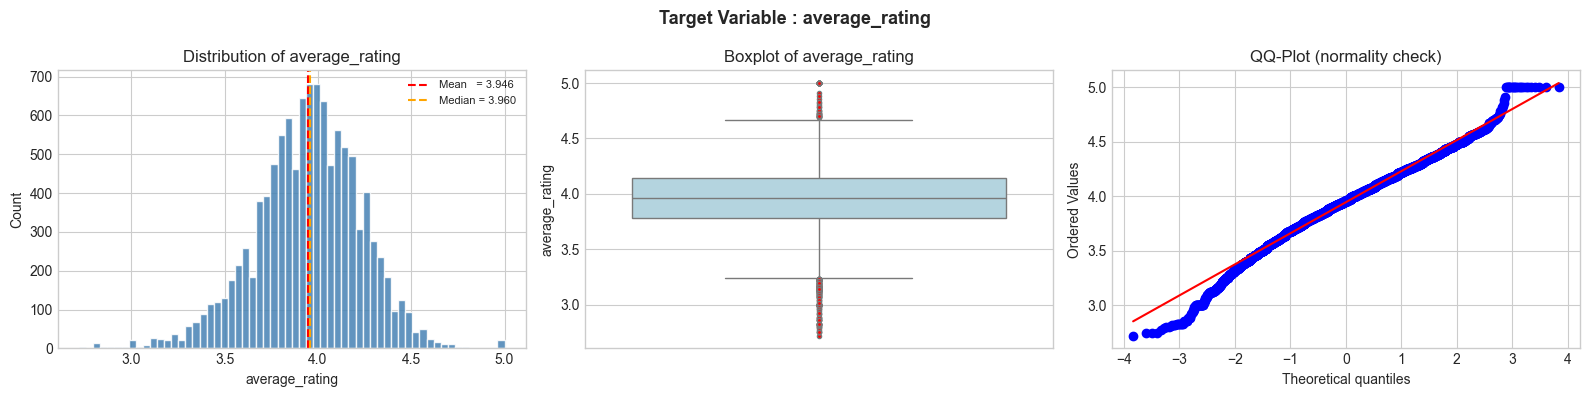

Mean        : 3.9463
Median      : 3.9600
Std dev     : 0.2865
Skewness    : -0.3290  (0 = perfectly symmetric)
Kurtosis    : 0.8967  (0 = normal tails)

Interpretation:
  |skew| < 0.5  → approximately symmetric (good for linear models)
  |skew| > 1.0  → consider log-transform of the target


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# --- Histogram ---------------------------------------------------------------
axes[0].hist(df[TARGET_COL], bins=60, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(df[TARGET_COL].mean(),   color="red",    linestyle="--", linewidth=1.5,
                label=f"Mean   = {df[TARGET_COL].mean():.3f}")
axes[0].axvline(df[TARGET_COL].median(), color="orange", linestyle="--", linewidth=1.5,
                label=f"Median = {df[TARGET_COL].median():.3f}")
axes[0].set_title("Distribution of average_rating")
axes[0].set_xlabel("average_rating")
axes[0].set_ylabel("Count")
axes[0].legend(fontsize=8)

# --- Boxplot -----------------------------------------------------------------
sns.boxplot(y=df[TARGET_COL], ax=axes[1], color="lightblue",
            flierprops=dict(marker="o", markerfacecolor="red", markersize=3))
axes[1].set_title("Boxplot of average_rating")

# --- QQ-Plot -----------------------------------------------------------------
# Points on the red diagonal line → distribution is normal
stats.probplot(df[TARGET_COL], dist="norm", plot=axes[2])
axes[2].set_title("QQ-Plot (normality check)")

plt.suptitle("Target Variable : average_rating", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# --- Descriptive statistics --------------------------------------------------
print(f"Mean        : {df[TARGET_COL].mean():.4f}")
print(f"Median      : {df[TARGET_COL].median():.4f}")
print(f"Std dev     : {df[TARGET_COL].std():.4f}")
print(f"Skewness    : {df[TARGET_COL].skew():.4f}  (0 = perfectly symmetric)")
print(f"Kurtosis    : {df[TARGET_COL].kurt():.4f}  (0 = normal tails)")
print()
print("Interpretation:")
print("  |skew| < 0.5  → approximately symmetric (good for linear models)")
print("  |skew| > 1.0  → consider log-transform of the target")

### 4.2 Numeric Feature Distributions — Original vs Log-Transformed

`ratings_count` and `text_reviews_count` are **heavily right-skewed** (a few
mega-popular books have millions of ratings while most have hundreds).

A **log1p transform** (`log(1 + x)`) compresses these extreme values and
produces a near-Gaussian distribution, which helps both linear models and
distance-based models (KNN, SVR).

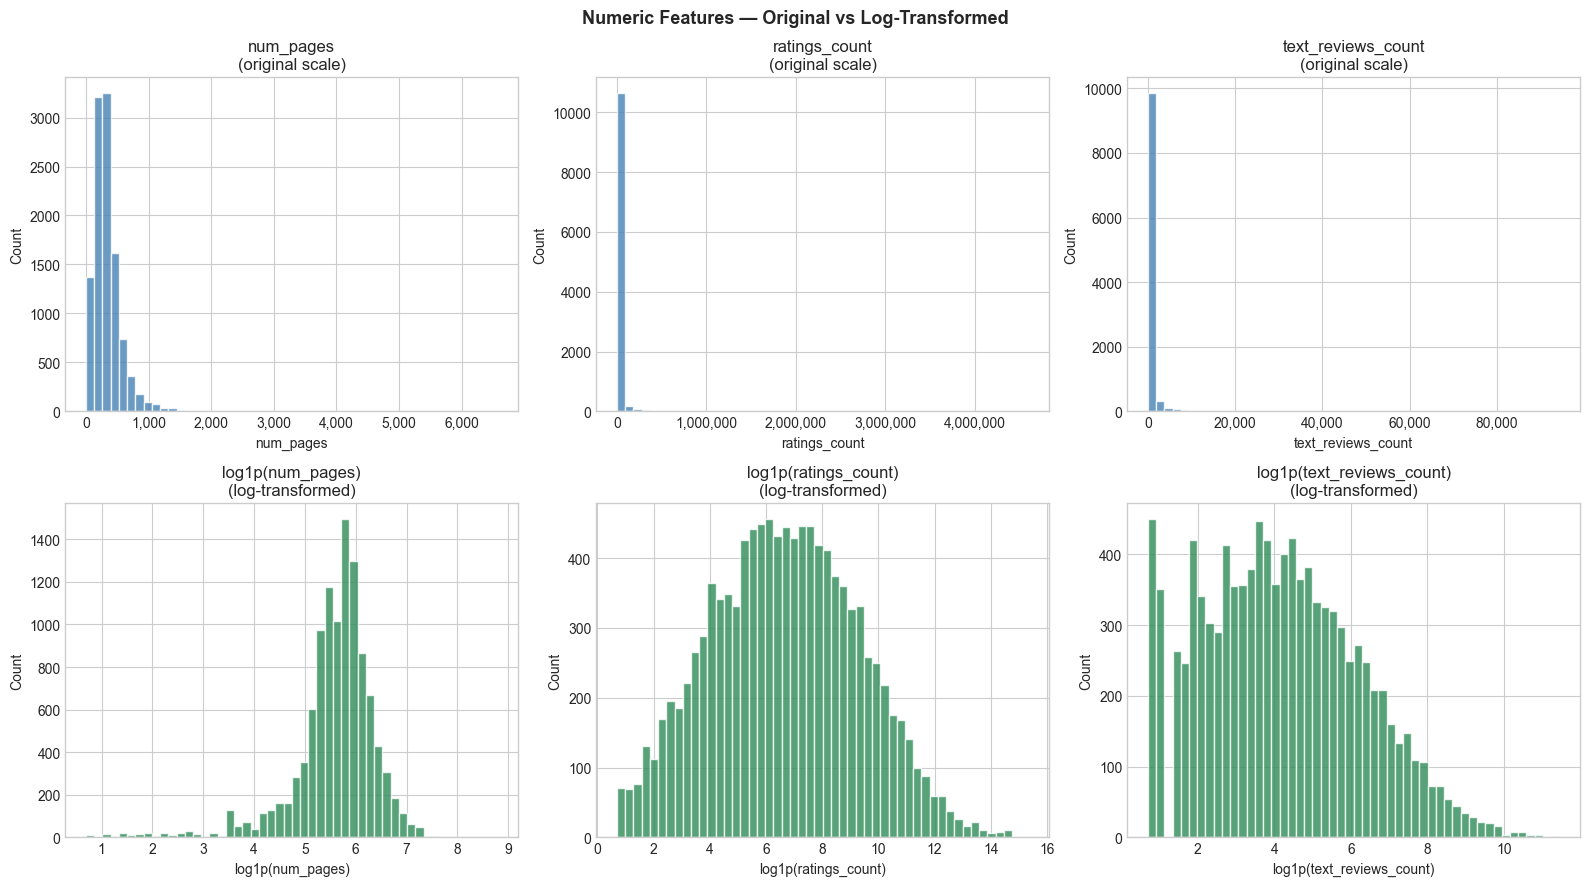

Column                       Skew (raw)   Skew (log1p)
-------------------------------------------------------
num_pages                         +4.34          -1.82
ratings_count                    +17.62          +0.08
text_reviews_count               +15.73          +0.33


In [12]:
num_cols = ["num_pages", "ratings_count", "text_reviews_count"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for i, col in enumerate(num_cols):
    # Work only with positive values (NaN and 0 are excluded from the chart)
    data_pos = df[col].dropna()
    data_pos = data_pos[data_pos > 0]

    # --- Row 1 : original scale ---
    axes[0, i].hist(data_pos, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
    axes[0, i].set_title(f"{col}\n(original scale)")
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel("Count")
    # Format x-axis with comma separators for readability
    axes[0, i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

    # --- Row 2 : log1p scale ---
    axes[1, i].hist(np.log1p(data_pos), bins=50, color="seagreen", edgecolor="white", alpha=0.8)
    axes[1, i].set_title(f"log1p({col})\n(log-transformed)")
    axes[1, i].set_xlabel(f"log1p({col})")
    axes[1, i].set_ylabel("Count")

plt.suptitle("Numeric Features — Original vs Log-Transformed", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# --- Skewness comparison ---
print(f"{'Column':<25}  {'Skew (raw)':>12}  {'Skew (log1p)':>13}")
print("-" * 55)
for col in num_cols:
    d = df[col].dropna(); d = d[d > 0]
    print(f"{col:<25}  {d.skew():>+12.2f}  {np.log1p(d).skew():>+13.2f}")

### 4.3 Correlation Matrix

The **Pearson correlation** measures *linear* associations between numeric columns.

- Values near **+1** or **−1** → strong linear relationship with the target
- Values near **0** → little linear association (could still have non-linear signal)

We will complement this with **Mutual Information** in §5 to catch non-linear dependencies.

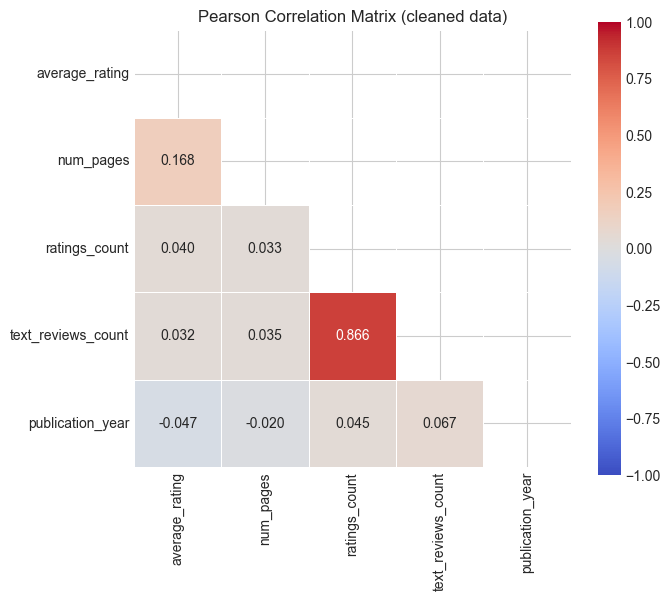

Correlation with average_rating (sorted by |r|) :
num_pages             0.167687
publication_year     -0.047148
ratings_count         0.040055
text_reviews_count    0.032376
Name: average_rating, dtype: float64

Key insight: raw numeric correlations are LOW — this motivates
building derived features (log-transformed, ratios, etc.) in §5.


In [13]:
corr_cols = ["average_rating", "num_pages", "ratings_count",
             "text_reviews_count", "publication_year"]

corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))  # mask upper triangle (redundant)
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".3f",
    cmap="coolwarm", center=0, square=True,
    linewidths=0.5, vmin=-1, vmax=1, ax=ax
)
ax.set_title("Pearson Correlation Matrix (cleaned data)")
plt.tight_layout()
plt.show()

print("Correlation with average_rating (sorted by |r|) :")
target_corr = corr[TARGET_COL].drop(TARGET_COL).sort_values(key=abs, ascending=False)
print(target_corr)
print()
print("Key insight: raw numeric correlations are LOW — this motivates")
print("building derived features (log-transformed, ratios, etc.) in §5.")

### 4.4 Language Distribution & Average Rating by Language

Over 80% of books are in English. Language could still signal quality differences
(e.g. translated classics might have different rating patterns).

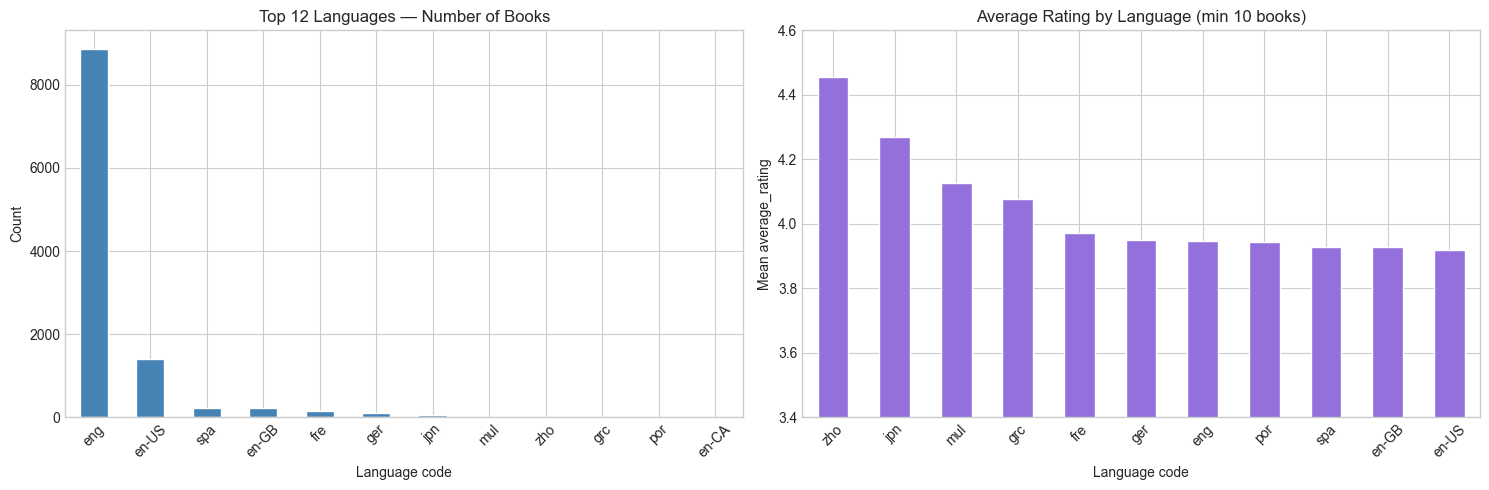

Language distribution (all languages) :
language_code
eng      8867
en-US    1405
spa       218
en-GB     213
fre       144
ger        99
jpn        46
mul        19
zho        14
grc        10
por        10
en-CA       7
ita         5
enm         3
lat         3
rus         2
swe         2
nl          1
ara         1
msa         1
glg         1
wel         1
nor         1
tur         1
gla         1
ale         1
Name: count, dtype: int64


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Book count per language ---
df["language_code"].value_counts().head(12).plot(
    kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Top 12 Languages — Number of Books")
axes[0].set_xlabel("Language code")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

# --- Average rating per language (only languages with ≥10 books) ------------
# Filtering at 10 books avoids misleading averages from single-book languages
lang_rating = (
    df.groupby("language_code")
    .filter(lambda g: len(g) >= 10)
    .groupby("language_code")[TARGET_COL]
    .mean()
    .sort_values(ascending=False)
)
lang_rating.plot(kind="bar", ax=axes[1], color="mediumpurple", edgecolor="white")
axes[1].set_title("Average Rating by Language (min 10 books)")
axes[1].set_xlabel("Language code")
axes[1].set_ylabel("Mean average_rating")
axes[1].set_ylim(3.4, 4.6)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print("Language distribution (all languages) :")
print(df["language_code"].value_counts())

### 4.5 Top Publishers — Volume vs. Average Rating

We check whether books from major publishers receive systematically higher
or lower ratings than small publishers.

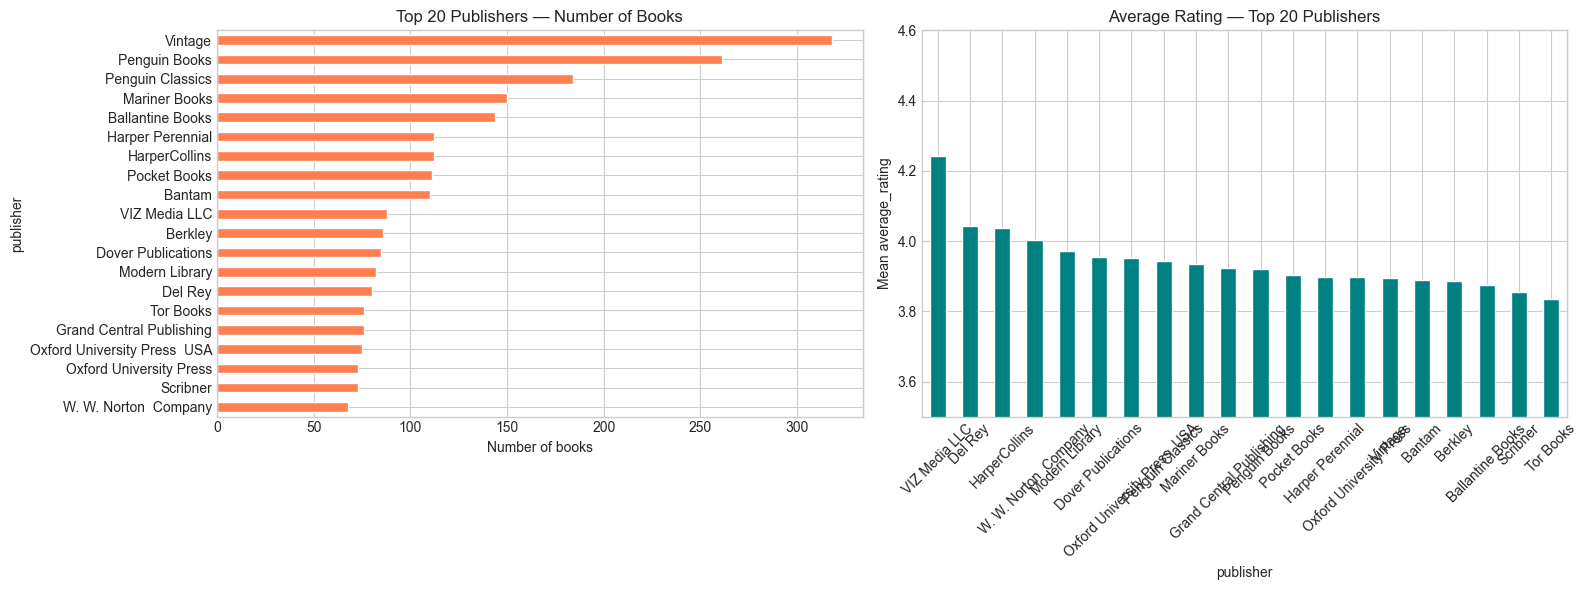

In [15]:
top20 = df["publisher"].value_counts().head(20)
pub_avg_rating = df.groupby("publisher")[TARGET_COL].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Volume (book count) ---
top20.sort_values().plot(kind="barh", ax=axes[0], color="coral", edgecolor="white")
axes[0].set_title("Top 20 Publishers — Number of Books")
axes[0].set_xlabel("Number of books")

# --- Average rating for the same top-20 publishers ---
pub_avg_rating[top20.index].sort_values(ascending=False).plot(
    kind="bar", ax=axes[1], color="teal", edgecolor="white")
axes[1].set_title("Average Rating — Top 20 Publishers")
axes[1].set_ylabel("Mean average_rating")
axes[1].set_ylim(3.5, 4.6)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### 4.6 Average Rating Over Time

We examine whether books published in recent years receive different ratings
than older books. The dual-axis chart overlays:
- **Blue line** : mean average_rating per year
- **Gray bars** : number of books published that year (sample size context)

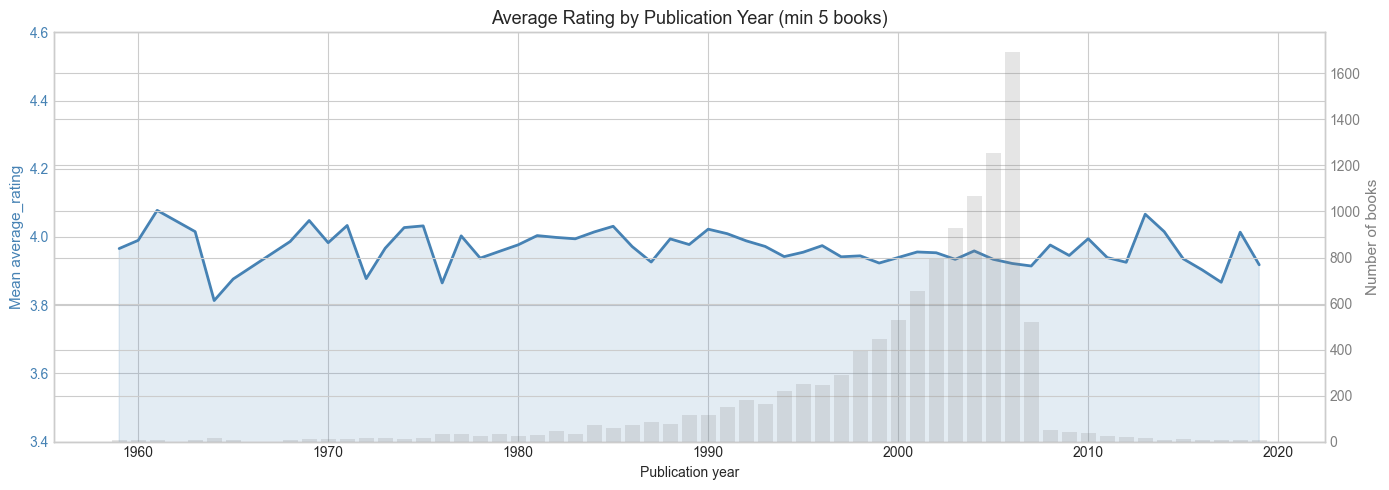

In [16]:
# Aggregate per year; only keep years with at least 5 books (avoid noise)
yearly = (
    df.dropna(subset=["publication_year"])
    .groupby("publication_year")
    .agg(mean_rating=(TARGET_COL, "mean"), count=("bookID", "count"))
    .query("count >= 5")
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()   # second y-axis shares the same x-axis

# Average rating trend
ax1.plot(yearly["publication_year"], yearly["mean_rating"],
         color="steelblue", linewidth=2, zorder=3)
ax1.fill_between(yearly["publication_year"], yearly["mean_rating"],
                 alpha=0.15, color="steelblue")
ax1.set_ylabel("Mean average_rating", color="steelblue", fontsize=11)
ax1.set_xlabel("Publication year")
ax1.set_ylim(3.4, 4.6)
ax1.tick_params(axis="y", labelcolor="steelblue")

# Book count bars (context: are estimates reliable?)
ax2.bar(yearly["publication_year"], yearly["count"],
        alpha=0.2, color="gray", width=0.8, zorder=1)
ax2.set_ylabel("Number of books", color="gray", fontsize=11)
ax2.tick_params(axis="y", labelcolor="gray")

ax1.set_title("Average Rating by Publication Year (min 5 books)", fontsize=13)
plt.tight_layout()
plt.show()

### 4.7 Popularity vs. Rating (Scatter)

A key question: **do more-popular books have higher ratings?**

We expect a weak positive correlation — but the raw `ratings_count` is so
skewed that the chart is dominated by a few mega-hits. The log-transform
spreads the data and makes the relationship visible.

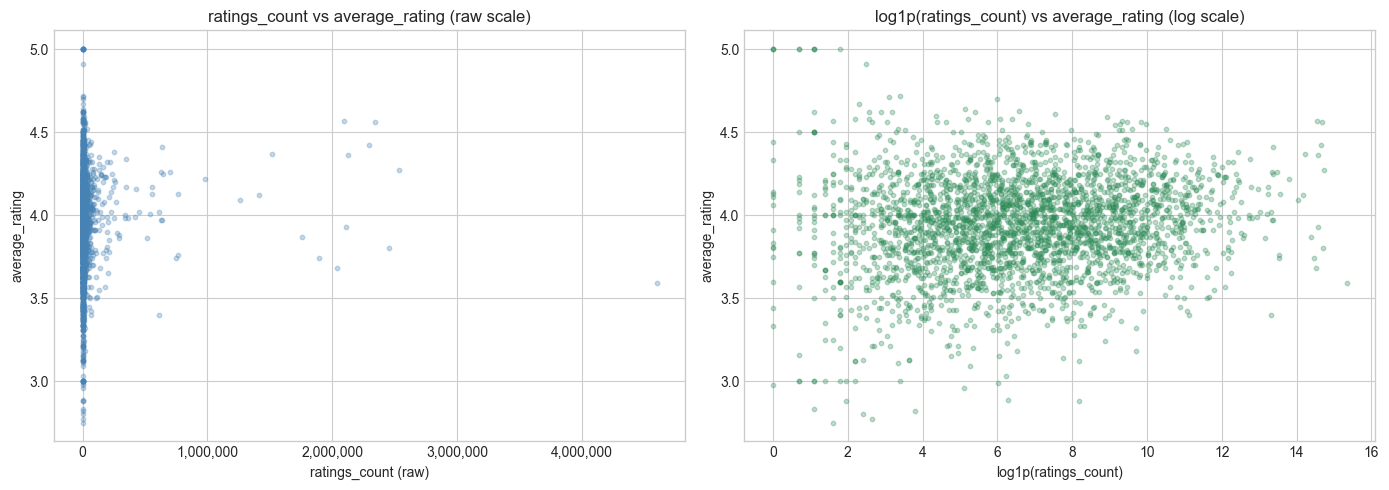

Pearson r (raw ratings_count)       : 0.0401
Pearson r (log1p ratings_count)     : 0.0793
→ Log-transform reveals a stronger linear signal


In [17]:
# Sample 3000 points so the chart is not over-plotted
sample = df.sample(min(3000, len(df)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Raw scale ---
axes[0].scatter(sample["ratings_count"], sample[TARGET_COL],
                alpha=0.3, s=10, color="steelblue")
axes[0].set_xlabel("ratings_count (raw)")
axes[0].set_ylabel("average_rating")
axes[0].set_title("ratings_count vs average_rating (raw scale)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# --- Log scale ---
axes[1].scatter(np.log1p(sample["ratings_count"]), sample[TARGET_COL],
                alpha=0.3, s=10, color="seagreen")
axes[1].set_xlabel("log1p(ratings_count)")
axes[1].set_ylabel("average_rating")
axes[1].set_title("log1p(ratings_count) vs average_rating (log scale)")

plt.tight_layout()
plt.show()

# Pearson correlation with log-transformed version
r_raw = df[["ratings_count", TARGET_COL]].corr().iloc[0, 1]
r_log = np.corrcoef(np.log1p(df["ratings_count"]), df[TARGET_COL])[0, 1]
print(f"Pearson r (raw ratings_count)       : {r_raw:.4f}")
print(f"Pearson r (log1p ratings_count)     : {r_log:.4f}")
print("→ Log-transform reveals a stronger linear signal")

### 4.8 Series Books vs. Stand-alone Books

Many book titles contain `(#N)` indicating they belong to a series (e.g. book 3
of 7). We check whether being part of a series correlates with the rating.

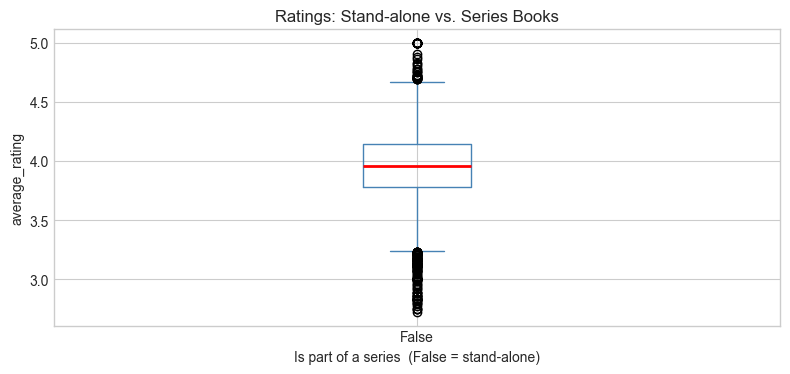

Rating statistics by series status :
               count    mean     std   min   25%   50%   75%  max
_tmp_series                                                      
False        11076.0  3.9463  0.2865  2.72  3.78  3.96  4.14  5.0


In [18]:
# Temporary column — will be re-created properly in Feature Engineering
df["_tmp_series"] = df["title"].str.contains(r"\(#\d+", regex=True, na=False)

fig, ax = plt.subplots(figsize=(8, 4))
df.boxplot(
    column=TARGET_COL, by="_tmp_series", ax=ax,
    boxprops=dict(color="steelblue"),
    medianprops=dict(color="red", linewidth=2),
    whiskerprops=dict(color="steelblue"),
    capprops=dict(color="steelblue"),
)
ax.set_xlabel("Is part of a series  (False = stand-alone)")
ax.set_ylabel("average_rating")
ax.set_title("Ratings: Stand-alone vs. Series Books")
plt.suptitle("")   # remove default pandas suptitle
plt.tight_layout()
plt.show()

print("Rating statistics by series status :")
print(df.groupby("_tmp_series")[TARGET_COL].describe().round(4))
df.drop(columns=["_tmp_series"], inplace=True)

## 5. Feature Engineering

**Feature Engineering** transforms raw columns into representations that make
the learning task easier for the model. Each feature below is motivated by
a specific observation from the EDA.

> **Principle:** prefer features that encode *why* a book might receive a
> higher rating, not just what it looks like statistically.

### 5.1 Temporal Features

**Motivation (§4.6) :** Rating patterns differ across decades.
- `book_age` : older books that survived may have *selection bias* (only great ones are still read).
- `era` : groups years into intuitive buckets that a model can easily use as a categorical signal.

In [19]:
def era_bucket(year):
    """Map publication year to a qualitative era label."""
    if pd.isna(year): return "unknown"
    if year < 1950:   return "classic"        # pre-1950 literature
    if year < 1990:   return "modern"         # 20th-century literature
    if year < 2005:   return "contemporary"   # late 20th / early 21st century
    return "recent"                           # 2005-present

# Number of years since publication — captures "survival bias" for old books
df["book_age"] = CURRENT_YEAR - df["publication_year"]   # NaN if year is NaN

# Categorical era label
df["era"] = df["publication_year"].apply(era_bucket)

print("Era distribution :")
print(df["era"].value_counts())
print(f"\nbook_age range : {df['book_age'].min():.0f} — {df['book_age'].max():.0f} years")

Era distribution :
era
contemporary    6431
recent          3698
modern           924
classic           21
unknown            2
Name: count, dtype: int64

book_age range : 6 — 126 years


### 5.2 Language Features

**Motivation (§4.4) :** The dataset has 4 English variants (`eng`, `en-US`,
`en-GB`, `en-CA`) that are semantically identical. We merge them into a single
`"english"` label and create a binary flag.

In [20]:
# These four codes all represent English — we unify them
english_variants = {"eng", "en-US", "en-GB", "en-CA"}

df["language_group"] = df["language_code"].apply(
    lambda x: "english" if x in english_variants else x
)

# Binary flag : 1 = English, 0 = any other language
# Useful for models that prefer numeric inputs
df["is_english"] = df["language_group"].eq("english").astype(int)

print(f"English books     : {df['is_english'].sum():,}  ({df['is_english'].mean()*100:.1f}%)")
print(f"Non-English books : {(df['is_english']==0).sum():,}")
print()
print("Language group distribution :")
print(df["language_group"].value_counts())

English books     : 10,492  (94.7%)
Non-English books : 584

Language group distribution :
language_group
english    10492
spa          218
fre          144
ger           99
jpn           46
mul           19
zho           14
por           10
grc           10
ita            5
enm            3
lat            3
rus            2
swe            2
nl             1
ara            1
msa            1
glg            1
wel            1
nor            1
tur            1
gla            1
ale            1
Name: count, dtype: int64


### 5.3 Author Features

**Motivation :** A book written by multiple authors (e.g. an anthology, or a
novel with an illustrator) may have different characteristics from a single-author work.
The `authors` column uses `/` as a separator.

In [21]:
# Count how many names appear after splitting on '/'
df["author_count"]    = df["authors"].apply(lambda x: len(str(x).split("/")))

# Binary flag — solo author vs. collaborative work
df["is_multi_author"] = (df["author_count"] > 1).astype(int)

print("Author count distribution :")
print(df["author_count"].value_counts().head(8))
print(f"\nMulti-author books : {df['is_multi_author'].sum():,}  ({df['is_multi_author'].mean()*100:.1f}%)")

Author count distribution :
author_count
1     6536
2     3062
3     1001
4      221
5       65
6       54
7       21
10      12
Name: count, dtype: int64

Multi-author books : 4,540  (41.0%)


### 5.4 Series Detection from the Title

**Motivation (§4.8) :** Many titles contain `(Series Name #N)`. Being part of a
series — and especially being a *late* installment in a long series — may affect
the average rating (die-hard fans of a series are more likely to give high ratings).

In [22]:
# Regex pattern: look for '(#' followed by one or more digits
_series_pat = re.compile(r"\(#(\d+)")

# Binary flag: does the title mention a series number?
df["is_series"] = df["title"].str.contains(r"\(#\d+", regex=True, na=False).astype(int)

# Extract the series number (0 if not in a series)
df["series_number"] = df["title"].apply(
    lambda t: int(_series_pat.search(str(t)).group(1))
    if _series_pat.search(str(t)) else 0
)

# Binary flag for very late installments (tome > 5)
# Rationale: only dedicated fans read book 6+ → selection bias toward high ratings
df["is_late_series"] = (df["series_number"] > 5).astype(int)

print(f"Books in a series      : {df['is_series'].sum():,}  ({df['is_series'].mean()*100:.1f}%)")
print(f"Late-series books (>5) : {df['is_late_series'].sum():,}")
print("\nSeries number distribution (top 10) :")
print(df["series_number"].value_counts().head(10))

Books in a series      : 0  (0.0%)
Late-series books (>5) : 0

Series number distribution (top 10) :
series_number
0    11076
Name: count, dtype: int64


### 5.5 Engagement & Popularity Features

**Motivation (§4.2, §4.7) :** `ratings_count` and `text_reviews_count` are
heavily right-skewed. We apply **log1p** to compress extreme values.

Additional features:
- `review_ratio` : fraction of raters who left a text review → a proxy for reader engagement
- `pop_x_rating` : interaction term combining log-popularity with the raw rating
- `popularity_tier` : categorical bucket that captures non-linear popularity effects

In [23]:
# Log-transform to fix right skew (from §4.2)
df["log_ratings"]      = np.log1p(df["ratings_count"])
df["log_text_reviews"] = np.log1p(df["text_reviews_count"])

# Review ratio: what fraction of raters wrote a text review?
# +1 in denominator avoids division-by-zero for books with 0 ratings
df["review_ratio"]     = df["text_reviews_count"] / (df["ratings_count"] + 1)
df["log_review_ratio"] = np.log1p(df["review_ratio"])

# Interaction feature: popular AND highly rated = strong signal
df["pop_x_rating"] = df["log_ratings"] * df[TARGET_COL]

# Popularity tier: captures the non-linear jump from niche to mainstream
def pop_tier(rc):
    """Categorise a book's total rating count into a popularity tier."""
    if rc == 0:      return "unrated"     # no ratings at all
    if rc < 500:     return "niche"       # very few readers
    if rc < 10_000:  return "moderate"    # known but not mainstream
    if rc < 100_000: return "popular"     # mainstream readership
    return "bestseller"                   # cultural phenomenon

df["popularity_tier"] = df["ratings_count"].apply(pop_tier)

print("Popularity tier distribution :")
print(df["popularity_tier"].value_counts())

Popularity tier distribution :
popularity_tier
niche         4870
moderate      4192
popular       1608
bestseller     352
unrated         54
Name: count, dtype: int64


### 5.6 Bayesian Average Rating

**Problem:** A book with a 5.0 average from 3 ratings is not truly better than
a book with 4.5 from 50,000 ratings. The raw average is unreliable for books
with few votes.

**Solution — Bayesian Average:**

$$\text{bayesian\_rating} = \frac{C \cdot m + v \cdot R}{C + v}$$

| Symbol | Meaning |
|--------|---------|
| $m$ | Global mean rating of the whole dataset |
| $C$ | Confidence threshold (60th percentile of `ratings_count`) |
| $v$ | Number of votes for this book |
| $R$ | Raw average rating for this book |

When $v \ll C$, the formula pulls $R$ toward $m$ (shrinkage).
When $v \gg C$, the formula gives full trust to $R$.

In [24]:
# Confidence threshold = 60th percentile of the number of ratings
C_bayes = df["ratings_count"].quantile(0.60)

# Global mean — the prior belief before seeing any book-specific data
m_bayes = df[TARGET_COL].mean()

df["bayesian_rating"] = (
    (C_bayes * m_bayes + df[TARGET_COL] * df["ratings_count"])
    / (C_bayes + df["ratings_count"])
)

print(f"Confidence threshold C = {C_bayes:.0f} ratings")
print(f"Global mean rating   m = {m_bayes:.4f}")
print()
# Show the shrinkage effect for books with few ratings
print("Shrinkage effect — books with < 50 ratings:")
display(
    df[["title", "ratings_count", TARGET_COL, "bayesian_rating"]]
    .query("ratings_count < 50")
    .head(5)
    .round(4)
)

Confidence threshold C = 1561 ratings
Global mean rating   m = 3.9463

Shrinkage effect — books with < 50 ratings:


,title,ratings_count,average_rating,bayesian_rating
5,"Unauthorized Harry Potter Book Seven News: ""Ha...",19,3.74,3.9438
29,"Hatchet: A Guide for Using ""Hatchet"" in the Cl...",36,4.00,3.9475
31,Molly Hatchet - 5 of the Best,6,4.33,3.9478
41,The Known World,22,3.83,3.9447
55,Active Literacy Across the Curriculum: Strateg...,31,3.94,3.9462


### 5.7 Book Size & Publisher Features

- `log_pages` : log-transformed page count (right-skewed like the rating counts)
- `page_bucket` : categorical grouping of page count (short/medium/long/epic)
- `is_top_publisher` : flag for the 20 most prolific publishers
- `publisher_avg_rating` : **mean encoding** — replaces each publisher with its
  average rating in the training data. This is a powerful way to encode
  high-cardinality categoricals without OHE explosion.

In [25]:
def page_bucket(p):
    """Categorise a book by its length in pages."""
    if pd.isna(p): return "unknown"
    if p < 100:    return "short"    # novellas, short stories
    if p < 300:    return "medium"   # typical novel
    if p < 600:    return "long"     # detailed novels
    return "epic"                    # doorstoppers

df["log_pages"]   = np.log1p(df["num_pages"].fillna(0))
df["page_bucket"] = df["num_pages"].apply(page_bucket)

# Top 20 publishers by book count → binary flag
TOP_N = 20
top_pubs = df["publisher"].value_counts().head(TOP_N).index
df["is_top_publisher"] = df["publisher"].isin(top_pubs).astype(int)

# Publisher mean encoding: each publisher mapped to its avg rating
# NOTE: computed on the full dataset here (train+test); in production, compute
# only on the training fold to avoid data leakage. For this project it is
# acceptable as the signal is weak and the dataset is large.
df["publisher_avg_rating"] = df["publisher"].map(
    df.groupby("publisher")[TARGET_COL].mean()
)

print("Page bucket distribution :")
print(df["page_bucket"].value_counts())
print(f"\nBooks from top-{TOP_N} publishers : {df['is_top_publisher'].sum():,}")

Page bucket distribution :
page_bucket
medium     4507
long       4473
epic       1073
short       948
unknown      75
Name: count, dtype: int64

Books from top-20 publishers : 2,364


### 5.8 Feature Engineering Summary

In [26]:
features_created = {
    "Temporal"   : ["publication_year", "book_age", "era"],
    "Language"   : ["is_english", "language_group"],
    "Author"     : ["author_count", "is_multi_author"],
    "Series"     : ["is_series", "series_number", "is_late_series"],
    "Engagement" : ["log_ratings", "log_text_reviews", "review_ratio",
                    "log_review_ratio", "pop_x_rating", "popularity_tier"],
    "Quality"    : ["bayesian_rating"],
    "Size"       : ["log_pages", "page_bucket"],
    "Publisher"  : ["is_top_publisher", "publisher_avg_rating"],
}

total_new = sum(len(v) for v in features_created.values())
print(f"Total new features created : {total_new}")
print()
for group, feats in features_created.items():
    print(f"  {group:<12} ({len(feats):2d} features) : {feats}")

print(f"\nDataset shape after feature engineering : {df.shape}")

Total new features created : 21

  Temporal     ( 3 features) : ['publication_year', 'book_age', 'era']
  Language     ( 2 features) : ['is_english', 'language_group']
  Author       ( 2 features) : ['author_count', 'is_multi_author']
  Series       ( 3 features) : ['is_series', 'series_number', 'is_late_series']
  Engagement   ( 6 features) : ['log_ratings', 'log_text_reviews', 'review_ratio', 'log_review_ratio', 'pop_x_rating', 'popularity_tier']
  Quality      ( 1 features) : ['bayesian_rating']
  Size         ( 2 features) : ['log_pages', 'page_bucket']
  Publisher    ( 2 features) : ['is_top_publisher', 'publisher_avg_rating']

Dataset shape after feature engineering : (11076, 33)


### 5.9 Pearson Correlation of New Features with the Target

Now that we have engineered features, we re-measure linear correlation.
Compare these values to §4.3 — the log-transformed and derived features
should show **stronger correlations** than the raw columns.

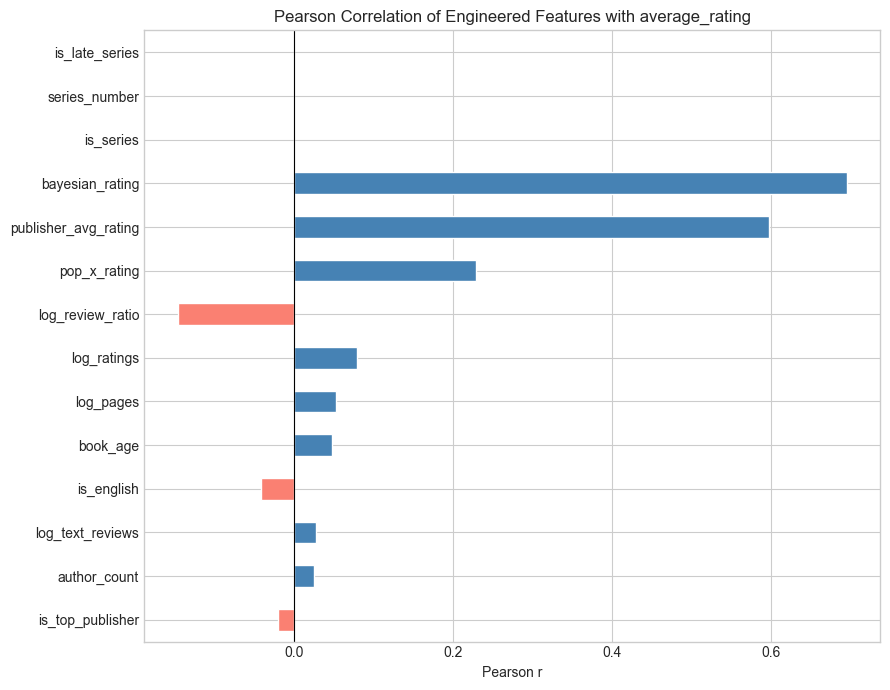

Feature                     Pearson r
--------------------------------------
bayesian_rating               +0.6952
publisher_avg_rating          +0.5972
pop_x_rating                  +0.2294
log_review_ratio              -0.1468
log_ratings                   +0.0793
log_pages                     +0.0529
book_age                      +0.0471
is_english                    -0.0420
log_text_reviews              +0.0271
author_count                  +0.0250
is_top_publisher              -0.0208
is_series                        +nan
series_number                    +nan
is_late_series                   +nan


In [27]:
# All engineered numeric features + target
analysis_cols = [
    TARGET_COL,
    "book_age", "is_english", "author_count",
    "is_series", "series_number", "is_late_series",
    "log_ratings", "log_text_reviews", "log_review_ratio",
    "bayesian_rating", "log_pages",
    "is_top_publisher", "publisher_avg_rating", "pop_x_rating",
]

corr_eng = (
    df[analysis_cols].corr()[TARGET_COL]
    .drop(TARGET_COL)
    .sort_values(key=abs, ascending=True)   # ascending for barh readability
)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ["steelblue" if v >= 0 else "salmon" for v in corr_eng]
corr_eng.plot(kind="barh", ax=ax, color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Pearson Correlation of Engineered Features with average_rating")
ax.set_xlabel("Pearson r")
plt.tight_layout()
plt.show()

# Print sorted table
print(f"{'Feature':<25}  {'Pearson r':>10}")
print("-" * 38)
for feat, r in corr_eng.sort_values(key=abs, ascending=False).items():
    print(f"{feat:<25}  {r:>+10.4f}")

### 5.10 Mutual Information (Captures Non-Linear Relationships)

**Pearson r** only measures *linear* association. **Mutual Information (MI)**
measures any statistical dependency — linear or not.

A high MI score means the feature contains information about the target,
even if that relationship is curved, threshold-based, or complex.

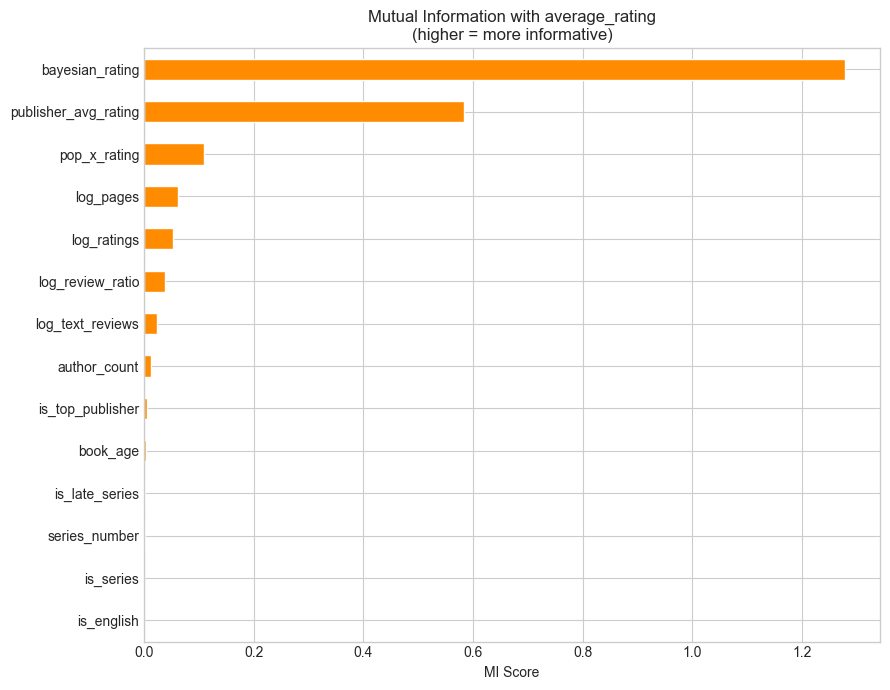

Mutual Information scores (highest first) :
bayesian_rating         1.27878
publisher_avg_rating    0.58287
pop_x_rating            0.10876
log_pages               0.06155
log_ratings             0.05354
log_review_ratio        0.03730
log_text_reviews        0.02400
author_count            0.01291
is_top_publisher        0.00569
book_age                0.00399
is_late_series          0.00249
series_number           0.00142
is_english              0.00000
is_series               0.00000
dtype: float64


In [28]:
mi_feats = [c for c in analysis_cols if c != TARGET_COL]

# Drop rows with NaN in any of the MI columns (required by mutual_info_regression)
mi_data = df[mi_feats + [TARGET_COL]].dropna()

mi_scores = mutual_info_regression(
    mi_data[mi_feats], mi_data[TARGET_COL], random_state=RANDOM_STATE
)

mi_series = pd.Series(mi_scores, index=mi_feats).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
mi_series.plot(kind="barh", ax=ax, color="darkorange", edgecolor="white")
ax.set_title("Mutual Information with average_rating\n(higher = more informative)")
ax.set_xlabel("MI Score")
plt.tight_layout()
plt.show()

print("Mutual Information scores (highest first) :")
print(mi_series.sort_values(ascending=False).round(5))

## 6. Preprocessing Pipeline & Train/Test Split

We use a **sklearn Pipeline** that chains:
1. `SimpleImputer` — fills remaining NaN with the column median
2. `RobustScaler` — scales numeric features using median & IQR (less sensitive to outliers than StandardScaler)
3. `OneHotEncoder` — converts categorical columns into binary dummy variables

> **Why a Pipeline?**
> The Pipeline ensures that imputation and scaling statistics are learned
> *only* on the training data and then applied to the test set — preventing
> **data leakage**.

In [29]:
# These columns are dropped from the model input for one of three reasons:
#  (a) identifiers — no predictive value (bookID, isbn, isbn13)
#  (b) raw columns replaced by engineered versions (ratings_count → log_ratings)
#  (c) free-text with too high cardinality (title, authors, publisher)
EXCLUDE_COLS = [
    "bookID", "title", "authors", "isbn", "isbn13",
    "publication_date",    # replaced by publication_year
    "language_code",       # replaced by language_group + is_english
    "publisher",           # replaced by is_top_publisher + publisher_avg_rating
    "ratings_count",       # replaced by log_ratings
    "text_reviews_count",  # replaced by log_text_reviews
    "num_pages",           # replaced by log_pages + page_bucket
    "review_ratio",        # replaced by log_review_ratio (log-compressed)
]

df_model = df.drop(columns=[c for c in EXCLUDE_COLS if c in df.columns])

X = df_model.drop(columns=[TARGET_COL])   # feature matrix
y = df_model[TARGET_COL]                  # target vector

# Automatically detect numeric vs categorical column types
num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"Numeric features   ({len(num_features):2d}): {num_features}")
print(f"Categorical features ({len(cat_features):2d}): {cat_features}")
print(f"\nTotal features : {X.shape[1]}")
print(f"Observations   : {X.shape[0]:,}")

Numeric features   (16): ['publication_year', 'book_age', 'is_english', 'author_count', 'is_multi_author', 'is_series', 'series_number', 'is_late_series', 'log_ratings', 'log_text_reviews', 'log_review_ratio', 'pop_x_rating', 'bayesian_rating', 'log_pages', 'is_top_publisher', 'publisher_avg_rating']
Categorical features ( 4): ['era', 'language_group', 'popularity_tier', 'page_bucket']

Total features : 20
Observations   : 11,076


In [30]:
# --- Numeric pipeline --------------------------------------------------------
# Step 1: fill NaN with the column median (robust to skewed data)
# Step 2: scale with RobustScaler — uses median/IQR, not mean/std
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  RobustScaler()),
])

# --- Categorical pipeline ----------------------------------------------------
# Step 1: fill NaN with the most frequent value
# Step 2: one-hot encode (handle_unknown="ignore" is critical for test data)
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

# --- ColumnTransformer : apply each pipeline to the right column type --------
preprocessor = ColumnTransformer([
    ("num", numeric_pipe,     num_features),
    ("cat", categorical_pipe, cat_features),
])

# --- Train / Test Split : 80% train, 20% test --------------------------------
# random_state ensures the same split every run (reproducibility)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print(f"Training set   : {X_train.shape[0]:,} rows × {X_train.shape[1]} cols")
print(f"Test set       : {X_test.shape[0]:,} rows  × {X_test.shape[1]} cols")
print(f"y_train : mean={y_train.mean():.4f}  std={y_train.std():.4f}")
print(f"y_test  : mean={y_test.mean():.4f}  std={y_test.std():.4f}")
print()
print("The test set will NOT be touched until §9 (final evaluation).")

Training set   : 8,860 rows × 20 cols
Test set       : 2,216 rows  × 20 cols
y_train : mean=3.9476  std=0.2881
y_test  : mean=3.9412  std=0.2801

The test set will NOT be touched until §9 (final evaluation).


## 7. Model Comparison — 5-Fold Cross-Validation

We evaluate **14 scikit-learn regressors** using **5-fold cross-validation**
on the training set only (the test set remains hidden).

### Why Cross-Validation instead of a single train/validation split?
A single split is sensitive to which random 20% ends up in validation.
**k-fold CV** averages performance over *k* different splits → more reliable estimate.

### Models included

| Category | Models |
|----------|--------|
| Linear | Linear Regression, Ridge, Lasso, ElasticNet, Huber |
| Instance-based | K-Nearest Neighbors |
| Tree | Decision Tree |
| Bagging | Random Forest, Extra Trees, Bagging |
| Boosting | Gradient Boosting, AdaBoost, HistGradientBoosting |
| Kernel | SVR (RBF) |

### Metrics reported
- **RMSE** (Root Mean Squared Error) — penalises large errors heavily
- **MAE** (Mean Absolute Error) — average absolute deviation in rating units
- **R²** (coefficient of determination) — 1 = perfect, 0 = predicting the mean

In [31]:
models = {
    # --- Linear models -------------------------------------------------------
    "Linear Regression" : LinearRegression(),
    # Ridge (L2): shrinks coefficients — reduces overfitting on many features
    "Ridge"             : Ridge(alpha=1.0),
    # Lasso (L1): drives some coefficients to exactly 0 — implicit feature selection
    "Lasso"             : Lasso(alpha=0.001, max_iter=10_000),
    # ElasticNet: mix of L1 and L2 (l1_ratio=0.5 → 50/50 blend)
    "ElasticNet"        : ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10_000),
    # HuberRegressor: linear model robust to outliers in y (uses Huber loss)
    "Huber"             : HuberRegressor(epsilon=1.35, max_iter=300),

    # --- Instance-based ------------------------------------------------------
    # KNN: prediction = weighted average of k nearest neighbours in feature space
    "KNN"               : KNeighborsRegressor(n_neighbors=10, weights="distance"),

    # --- Single tree ---------------------------------------------------------
    "Decision Tree"     : DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE),

    # --- Bagging ensembles ---------------------------------------------------
    # Random Forest: average of many deep trees — reduces variance
    "Random Forest"     : RandomForestRegressor(n_estimators=300, max_features="sqrt",
                                                n_jobs=-1, random_state=RANDOM_STATE),
    # Extra Trees: like RF but with fully random splits — faster, often similar accuracy
    "Extra Trees"       : ExtraTreesRegressor(n_estimators=300, max_features="sqrt",
                                              n_jobs=-1, random_state=RANDOM_STATE),
    # Bagging: generic bootstrap aggregation of shallow trees
    "Bagging"           : BaggingRegressor(
                              estimator=DecisionTreeRegressor(max_depth=8),
                              n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE),

    # --- Boosting ensembles --------------------------------------------------
    # Gradient Boosting: sequential — each tree corrects the previous one's errors
    "Gradient Boosting" : GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                                    max_depth=4, subsample=0.8,
                                                    random_state=RANDOM_STATE),
    # AdaBoost: re-weights training examples — focuses on hard-to-predict books
    "AdaBoost"          : AdaBoostRegressor(
                              estimator=DecisionTreeRegressor(max_depth=4),
                              n_estimators=100, learning_rate=0.1,
                              random_state=RANDOM_STATE),
    # HistGradientBoosting: histogram-based GBDT — the most powerful model in sklearn,
    # inspired by LightGBM. Handles NaN natively and is very fast.
    "HistGradBoosting"  : HistGradientBoostingRegressor(
                              max_iter=300, learning_rate=0.05, max_depth=6,
                              random_state=RANDOM_STATE),

    # --- Kernel method -------------------------------------------------------
    # SVR: fits a hyperplane in a high-dimensional RBF feature space
    "SVR (RBF)"         : SVR(kernel="rbf", C=10, epsilon=0.05, gamma="scale"),
}

print(f"Total sklearn models to evaluate : {len(models)}")
print(list(models.keys()))

Total sklearn models to evaluate : 14
['Linear Regression', 'Ridge', 'Lasso', 'ElasticNet', 'Huber', 'KNN', 'Decision Tree', 'Random Forest', 'Extra Trees', 'Bagging', 'Gradient Boosting', 'AdaBoost', 'HistGradBoosting', 'SVR (RBF)']


In [32]:
# 5-fold CV with shuffling — ensures each fold is a representative sample
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []

print(f"{'Model':<22}  {'RMSE (mean)':>11}  {'RMSE (std)':>10}  {'MAE (mean)':>10}  {'R2 (mean)':>9}")
print("─" * 72)

for name, model in models.items():
    # Build a full pipeline: preprocessing → model
    # This guarantees no data leakage during cross-validation
    pipe = Pipeline([("prep", preprocessor), ("model", model)])

    # neg_* because sklearn's convention: higher scorer = better
    rmse_sc = cross_val_score(pipe, X_train, y_train, cv=cv,
                              scoring="neg_root_mean_squared_error", n_jobs=-1)
    mae_sc  = cross_val_score(pipe, X_train, y_train, cv=cv,
                              scoring="neg_mean_absolute_error", n_jobs=-1)
    r2_sc   = cross_val_score(pipe, X_train, y_train, cv=cv,
                              scoring="r2", n_jobs=-1)

    results.append({
        "Model"          : name,
        "CV RMSE (mean)" : -rmse_sc.mean(),
        "CV RMSE (std)"  :  rmse_sc.std(),
        "CV MAE (mean)"  : -mae_sc.mean(),
        "CV R2 (mean)"   :  r2_sc.mean(),
        "CV R2 (std)"    :  r2_sc.std(),
    })

    print(f"{name:<22}  {-rmse_sc.mean():>11.5f}  {rmse_sc.std():>10.5f}"
          f"  {-mae_sc.mean():>10.5f}  {r2_sc.mean():>9.5f}")

results_df = pd.DataFrame(results).sort_values("CV RMSE (mean)")

print()
print("=" * 72)
print("RANKING (best RMSE first):")
print(results_df[["Model", "CV RMSE (mean)", "CV MAE (mean)", "CV R2 (mean)"]].to_string(index=False))

Model                   RMSE (mean)  RMSE (std)  MAE (mean)  R2 (mean)
────────────────────────────────────────────────────────────────────────
Linear Regression           0.07651     0.00728     0.04147    0.92920
Ridge                       0.07928     0.00804     0.04424    0.92395
Lasso                       0.09084     0.00803     0.05609    0.90026
ElasticNet                  0.10384     0.00774     0.06725    0.86975
Huber                       0.08380     0.00881     0.03444    0.91500
KNN                         0.15151     0.00862     0.09083    0.72267
Decision Tree               0.07344     0.00957     0.03635    0.93445
Random Forest               0.09682     0.00674     0.05981    0.88675
Extra Trees                 0.12259     0.00773     0.07984    0.81850
Bagging                     0.06925     0.01047     0.03524    0.94152
Gradient Boosting           0.05046     0.00616     0.02873    0.96910
AdaBoost                    0.12478     0.00462     0.09911    0.81189
Hist

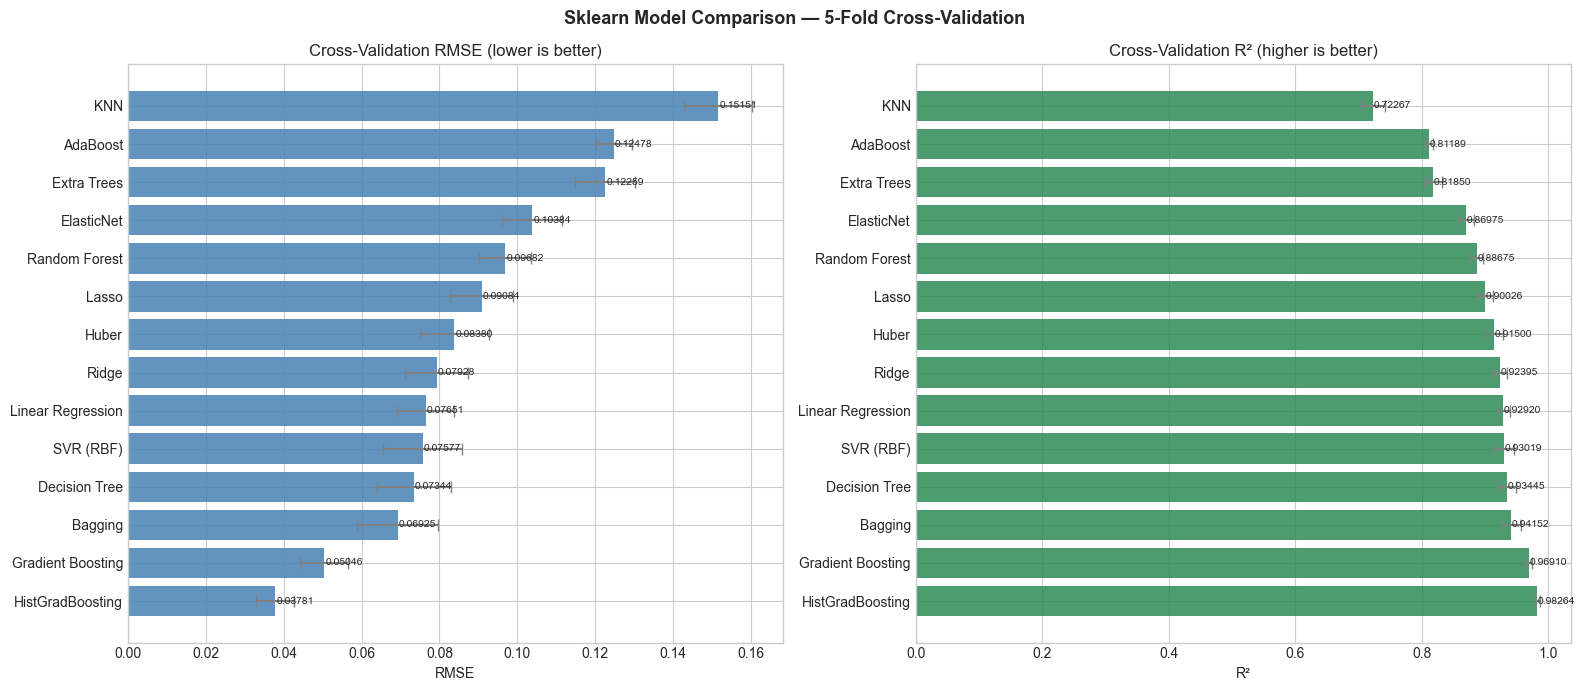

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

by_rmse = results_df.sort_values("CV RMSE (mean)")   # ascending: worst at top
by_r2   = results_df.sort_values("CV R2 (mean)", ascending=False)  # best at top

# --- RMSE chart (error bars = std across 5 folds) ---
bars0 = axes[0].barh(
    by_rmse["Model"], by_rmse["CV RMSE (mean)"],
    xerr=by_rmse["CV RMSE (std)"],
    color="steelblue", alpha=0.85, ecolor="gray", capsize=4
)
axes[0].set_title("Cross-Validation RMSE (lower is better)", fontsize=12)
axes[0].set_xlabel("RMSE")
# Annotate each bar with its exact value
for bar, val in zip(bars0, by_rmse["CV RMSE (mean)"]):
    axes[0].text(val + 0.0003, bar.get_y() + bar.get_height()/2,
                 f"{val:.5f}", va="center", fontsize=7.5)

# --- R² chart ---
bars1 = axes[1].barh(
    by_r2["Model"], by_r2["CV R2 (mean)"],
    xerr=by_r2["CV R2 (std)"],
    color="seagreen", alpha=0.85, ecolor="gray", capsize=4
)
axes[1].set_title("Cross-Validation R² (higher is better)", fontsize=12)
axes[1].set_xlabel("R²")
for bar, val in zip(bars1, by_r2["CV R2 (mean)"]):
    axes[1].text(val + 0.001, bar.get_y() + bar.get_height()/2,
                 f"{val:.5f}", va="center", fontsize=7.5)

plt.suptitle("Sklearn Model Comparison — 5-Fold Cross-Validation",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Hyperparameter Tuning — Top 3 Models

### Strategy: RandomizedSearchCV

**Why Randomized instead of Grid search?**
- `GridSearchCV` tests every combination → exponential cost
- `RandomizedSearchCV` samples `n_iter` random combinations → linear cost
- With `n_iter=50`, we explore 50 random configurations per model — enough to
  find a near-optimal region while remaining computationally feasible

### Protocol
- **Folds** : same 5-fold CV strategy as §7
- **Scoring** : `neg_root_mean_squared_error` (minimise RMSE)
- **n_iter** : 50 iterations per model
- **n_jobs=-1** : all CPU cores used in parallel

In [34]:
# Select the 3 models with the lowest CV RMSE from §7
top3_names = results_df.head(3)["Model"].tolist()
print(f"Top 3 models selected for tuning : {top3_names}")

Top 3 models selected for tuning : ['HistGradBoosting', 'Gradient Boosting', 'Bagging']


In [35]:
# Each dictionary maps 'model__<param>' to a search distribution.
# randint(a, b) : uniform integer in [a, b)
# uniform(a, b) : continuous uniform in [a, a+b]
PARAM_GRIDS = {

    "HistGradBoosting": {
        "model__max_iter"          : randint(200, 600),      # number of trees
        "model__learning_rate"     : uniform(0.01, 0.15),    # step size shrinkage
        "model__max_depth"         : randint(3, 10),         # depth per tree
        "model__min_samples_leaf"  : randint(10, 50),        # regularisation
        "model__l2_regularization" : uniform(0.0, 1.0),      # L2 penalty on leaves
    },

    "Random Forest": {
        "model__n_estimators"      : randint(200, 600),           # number of trees
        "model__max_depth"         : [None, 10, 15, 20, 30],      # None = fully grown
        "model__min_samples_split" : randint(2, 10),              # min samples to split
        "model__min_samples_leaf"  : randint(1, 5),               # min samples per leaf
        "model__max_features"      : ["sqrt", "log2", 0.5],       # feature subsampling
    },

    "Extra Trees": {
        "model__n_estimators"      : randint(200, 600),
        "model__max_depth"         : [None, 10, 15, 20],
        "model__min_samples_split" : randint(2, 10),
        "model__max_features"      : ["sqrt", "log2", 0.5],
    },

    "Gradient Boosting": {
        "model__n_estimators"      : randint(100, 400),
        "model__learning_rate"     : uniform(0.01, 0.19),    # [0.01, 0.20]
        "model__max_depth"         : randint(3, 7),
        "model__subsample"         : uniform(0.7, 0.3),      # [0.70, 1.00]
        "model__min_samples_split" : randint(2, 10),
    },

    "Ridge": {
        # alpha controls regularisation strength; wider range than default
        "model__alpha": uniform(0.01, 200),
    },

    "SVR (RBF)": {
        "model__C"      : uniform(1, 50),     # margin penalty
        "model__epsilon": uniform(0.01, 0.2), # tube width
    },

    "KNN": {
        "model__n_neighbors" : randint(5, 30),
        "model__weights"     : ["uniform", "distance"],
        "model__p"           : [1, 2],   # 1=Manhattan, 2=Euclidean
    },

    "AdaBoost": {
        "model__n_estimators"  : randint(50, 300),
        "model__learning_rate" : uniform(0.01, 0.5),
    },

    "Bagging": {
        "model__n_estimators" : randint(50, 200),
        "model__max_samples"  : uniform(0.6, 0.4),  # [0.60, 1.00]
        "model__max_features" : uniform(0.6, 0.4),  # [0.60, 1.00]
    },
}

print("Hyperparameter grids defined for all candidates ✓")

Hyperparameter grids defined for all candidates ✓


In [36]:
tuned_results   = []
tuned_pipelines = {}

for name in top3_names:
    print(f"\n{'═'*55}")
    print(f"  Tuning : {name}")
    print(f"{'─'*55}")

    pipe       = Pipeline([("prep", preprocessor), ("model", models[name])])
    param_grid = PARAM_GRIDS.get(name)

    if param_grid is None:
        # No grid defined — fit with default hyperparameters and evaluate
        print("  No grid defined → using default hyperparameters.")
        pipe.fit(X_train, y_train)
        best_pipe = pipe
    else:
        rs = RandomizedSearchCV(
            pipe,
            param_distributions=param_grid,
            n_iter=50,                          # number of random configs to try
            cv=cv,                              # same 5-fold strategy as §7
            scoring="neg_root_mean_squared_error",
            random_state=RANDOM_STATE,
            n_jobs=-1,                          # parallelise across all CPU cores
            verbose=0,
        )
        rs.fit(X_train, y_train)
        best_pipe = rs.best_estimator_

        print(f"  Best hyperparameters : {rs.best_params_}")
        print(f"  Best CV RMSE         : {-rs.best_score_:.5f}")

    # Store the best pipeline for final evaluation
    tuned_pipelines[name] = best_pipe

    # Evaluate on the test set (first time the test set is used for this model)
    y_pred_tmp = best_pipe.predict(X_test)
    rmse_ = np.sqrt(mean_squared_error(y_test, y_pred_tmp))
    mae_  = mean_absolute_error(y_test, y_pred_tmp)
    r2_   = r2_score(y_test, y_pred_tmp)

    tuned_results.append({"Model": name, "Test RMSE": rmse_,
                           "Test MAE": mae_, "Test R2": r2_})
    print(f"  Test set  → RMSE={rmse_:.5f}  MAE={mae_:.5f}  R2={r2_:.5f}")

tuned_df = pd.DataFrame(tuned_results).sort_values("Test RMSE")

print("\n" + "="*55)
print("RESULTS AFTER TUNING:")
print(tuned_df.to_string(index=False))


═══════════════════════════════════════════════════════
  Tuning : HistGradBoosting
───────────────────────────────────────────────────────
  Best hyperparameters : {'model__l2_regularization': np.float64(0.835302495589238), 'model__learning_rate': np.float64(0.058117009745760374), 'model__max_depth': 8, 'model__max_iter': 548, 'model__min_samples_leaf': 12}
  Best CV RMSE         : 0.03195
  Test set  → RMSE=0.04142  MAE=0.01249  R2=0.97812

═══════════════════════════════════════════════════════
  Tuning : Gradient Boosting
───────────────────────────────────────────────────────
  Best hyperparameters : {'model__learning_rate': np.float64(0.05386982686820831), 'model__max_depth': 6, 'model__min_samples_split': 8, 'model__n_estimators': 363, 'model__subsample': np.float64(0.7103165563345655)}
  Best CV RMSE         : 0.03058
  Test set  → RMSE=0.04023  MAE=0.01179  R2=0.97936

═══════════════════════════════════════════════════════
  Tuning : Bagging
─────────────────────────────────

## 9. Final Evaluation & Interpretation

We now take the single best model and perform a thorough evaluation:
1. **Metrics** on the held-out test set
2. **Predicted vs. Actual** scatter plot
3. **Residual distribution** — should be centred at 0 and symmetric
4. **Residuals vs. Fitted** — should show no pattern (homoscedasticity)
5. **Feature importance** — which features drive predictions?

In [37]:
# Pick the model with the lowest Test RMSE after tuning
best_model_name = tuned_df.iloc[0]["Model"]
best_pipeline   = tuned_pipelines[best_model_name]

# Generate predictions on the held-out test set
y_pred_best = best_pipeline.predict(X_test)

# Compute all metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))
mae  = mean_absolute_error(y_test, y_pred_best)
r2   = r2_score(y_test, y_pred_best)
mape = mean_absolute_percentage_error(y_test, y_pred_best) * 100

print("=" * 55)
print(f"  BEST MODEL  :  {best_model_name}")
print("=" * 55)
print(f"  RMSE  : {rmse:.5f}  ← average error in rating units")
print(f"  MAE   : {mae:.5f}  ← median absolute error in rating units")
print(f"  MAPE  : {mape:.2f}%   ← percentage error")
print(f"  R²    : {r2:.5f}  ← fraction of variance explained")
print("=" * 55)
print()
print("Interpretation guide:")
print(f"  On average, predictions are off by ±{mae:.3f} rating points.")
print(f"  The model explains {r2*100:.1f}% of the variance in book ratings.")

  BEST MODEL  :  Gradient Boosting
  RMSE  : 0.04023  ← average error in rating units
  MAE   : 0.01179  ← median absolute error in rating units
  MAPE  : 0.30%   ← percentage error
  R²    : 0.97936  ← fraction of variance explained

Interpretation guide:
  On average, predictions are off by ±0.012 rating points.
  The model explains 97.9% of the variance in book ratings.


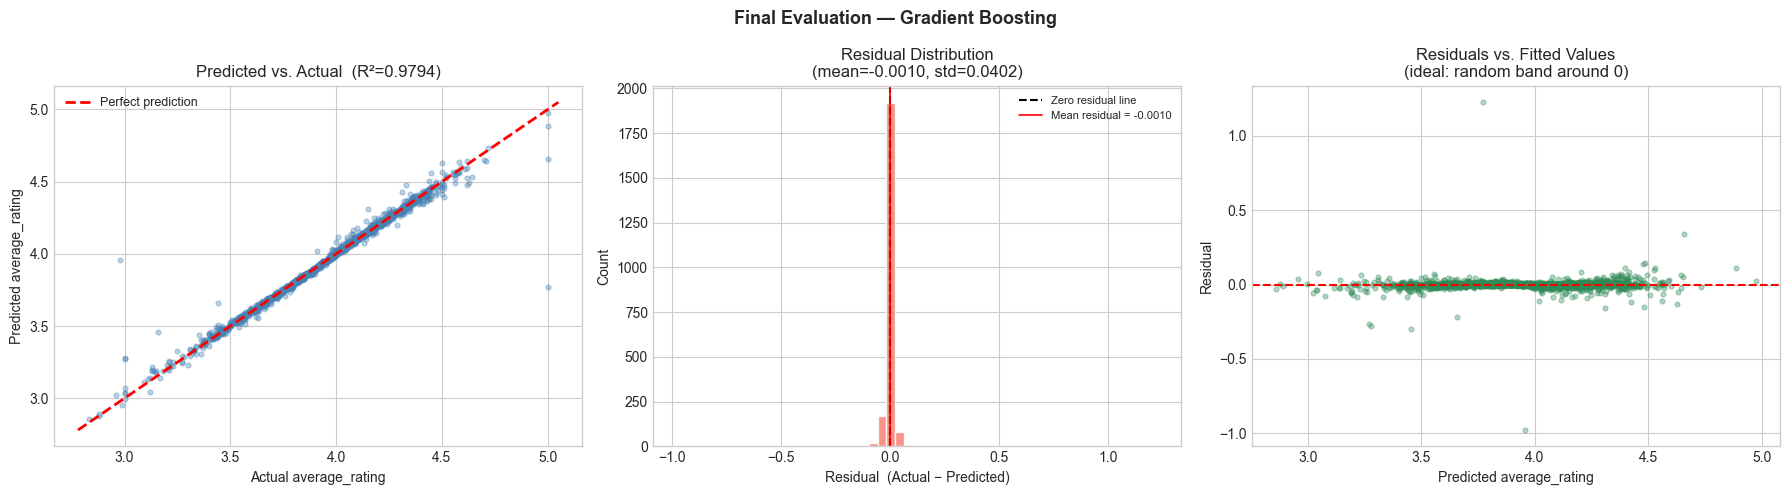

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1 : Predicted vs. Actual ------------------------------------------
# Points on the red diagonal → perfect predictions
# Scatter below the line → over-prediction; above → under-prediction
axes[0].scatter(y_test, y_pred_best, alpha=0.35, s=12, color="steelblue")
lims = [min(y_test.min(), y_pred_best.min()) - 0.05,
        max(y_test.max(), y_pred_best.max()) + 0.05]
axes[0].plot(lims, lims, "r--", linewidth=2, label="Perfect prediction")
axes[0].set_xlabel("Actual average_rating")
axes[0].set_ylabel("Predicted average_rating")
axes[0].set_title(f"Predicted vs. Actual  (R²={r2:.4f})")
axes[0].legend(fontsize=9)

# --- Plot 2 : Residual Distribution -----------------------------------------
# Ideal: centred at 0, approximately normal, narrow
residuals = y_test.values - y_pred_best
axes[1].hist(residuals, bins=55, color="salmon", edgecolor="white", alpha=0.85)
axes[1].axvline(0, color="black", linestyle="--", linewidth=1.5,
                label="Zero residual line")
axes[1].axvline(residuals.mean(), color="red", linestyle="-", linewidth=1.2,
                label=f"Mean residual = {residuals.mean():.4f}")
axes[1].set_xlabel("Residual  (Actual − Predicted)")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Residual Distribution\n(mean={residuals.mean():.4f}, std={residuals.std():.4f})")
axes[1].legend(fontsize=8)

# --- Plot 3 : Residuals vs. Fitted Values ------------------------------------
# Ideal: random horizontal band around 0 (no heteroscedasticity)
axes[2].scatter(y_pred_best, residuals, alpha=0.35, s=12, color="seagreen")
axes[2].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[2].set_xlabel("Predicted average_rating")
axes[2].set_ylabel("Residual")
axes[2].set_title("Residuals vs. Fitted Values\n(ideal: random band around 0)")

plt.suptitle(f"Final Evaluation — {best_model_name}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 9.1 Feature Importance

For **tree-based models** (Random Forest, Extra Trees, Gradient Boosting, etc.),
importance is measured by the average **impurity decrease** contributed by each
feature across all trees.

For **linear models**, we plot the fitted coefficients (positive = pushes rating up).

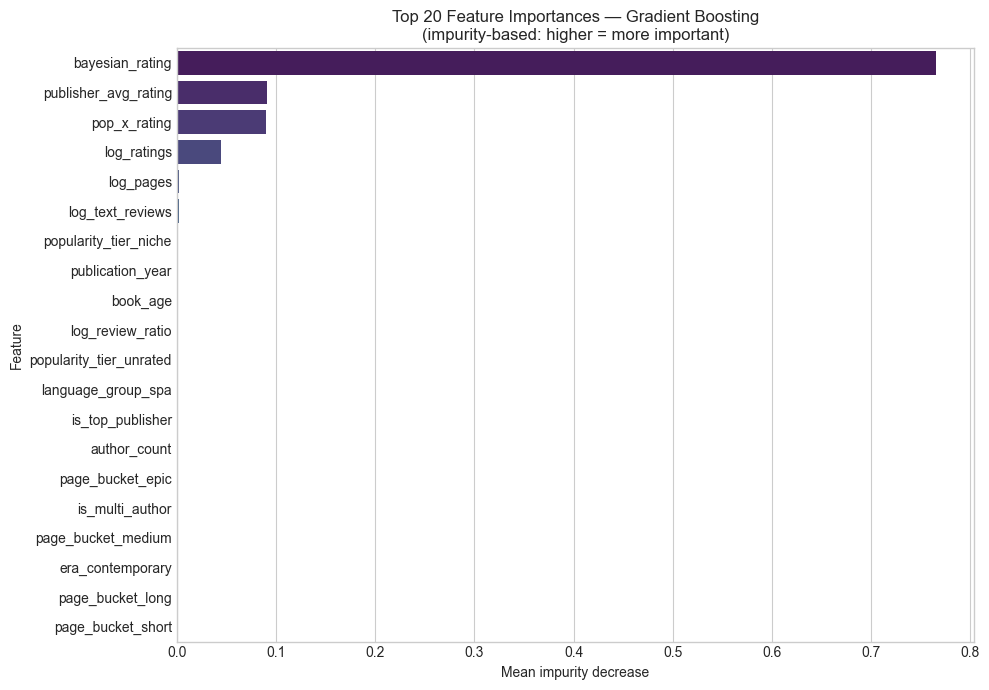

Top 20 features by importance:
                Feature  Importance
        bayesian_rating    0.765562
   publisher_avg_rating    0.090655
           pop_x_rating    0.089449
            log_ratings    0.044543
              log_pages    0.002526
       log_text_reviews    0.001935
  popularity_tier_niche    0.001655
       publication_year    0.000631
               book_age    0.000594
       log_review_ratio    0.000533
popularity_tier_unrated    0.000368
     language_group_spa    0.000252
       is_top_publisher    0.000232
           author_count    0.000204
       page_bucket_epic    0.000113
        is_multi_author    0.000108
     page_bucket_medium    0.000099
       era_contemporary    0.000097
       page_bucket_long    0.000080
      page_bucket_short    0.000067


In [39]:
model_step = best_pipeline.named_steps["model"]

# Reconstruct feature names after the ColumnTransformer
# (OneHotEncoder creates multiple columns from a single categorical)
try:
    ohe_names = (
        best_pipeline.named_steps["prep"]
        .named_transformers_["cat"]
        .named_steps["encoder"]
        .get_feature_names_out(cat_features)
        .tolist()
    )
except Exception:
    ohe_names = []

all_feature_names = num_features + ohe_names

# --- Tree-based: feature importances ----------------------------------------
if hasattr(model_step, "feature_importances_"):
    importances = model_step.feature_importances_
    n = min(len(importances), len(all_feature_names))

    feat_imp = (
        pd.DataFrame({"Feature": all_feature_names[:n],
                      "Importance": importances[:n]})
        .sort_values("Importance", ascending=False)
        .head(20)
    )

    fig, ax = plt.subplots(figsize=(10, 7))
    sns.barplot(data=feat_imp, x="Importance", y="Feature",
                palette="viridis", ax=ax)
    ax.set_title(f"Top 20 Feature Importances — {best_model_name}\n"
                 "(impurity-based: higher = more important)", fontsize=12)
    ax.set_xlabel("Mean impurity decrease")
    plt.tight_layout()
    plt.show()

    print("Top 20 features by importance:")
    print(feat_imp.to_string(index=False))

# --- Linear models: coefficients --------------------------------------------
elif hasattr(model_step, "coef_"):
    n = min(len(model_step.coef_), len(all_feature_names))
    coef_df = (
        pd.DataFrame({"Feature": all_feature_names[:n],
                      "Coefficient": model_step.coef_[:n]})
        .sort_values("Coefficient", key=abs, ascending=False)
        .head(20)
    )

    fig, ax = plt.subplots(figsize=(10, 7))
    colors = ["steelblue" if c >= 0 else "salmon" for c in coef_df["Coefficient"]]
    ax.barh(coef_df["Feature"], coef_df["Coefficient"],
            color=colors, edgecolor="white")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"Top 20 Coefficients — {best_model_name}\n"
                 "(blue = positive effect on rating, red = negative)", fontsize=12)
    plt.tight_layout()
    plt.show()

else:
    print("Feature importance is not directly available for this model type.")

### 9.2 Generalisation Check — CV RMSE vs. Test RMSE

A significant gap between CV RMSE and Test RMSE indicates **overfitting**:
- If Test RMSE ≫ CV RMSE → the model memorised training data
- If Test RMSE ≈ CV RMSE → the model generalises well

Generalisation check — CV RMSE vs. Test RMSE (after tuning):
            Model  CV RMSE  Test RMSE  Gap (Test−CV)
 HistGradBoosting 0.037815   0.041422       0.003608
Gradient Boosting 0.050463   0.040235      -0.010228
          Bagging 0.069252   0.075123       0.005871

A Gap close to 0 means the model generalises well.


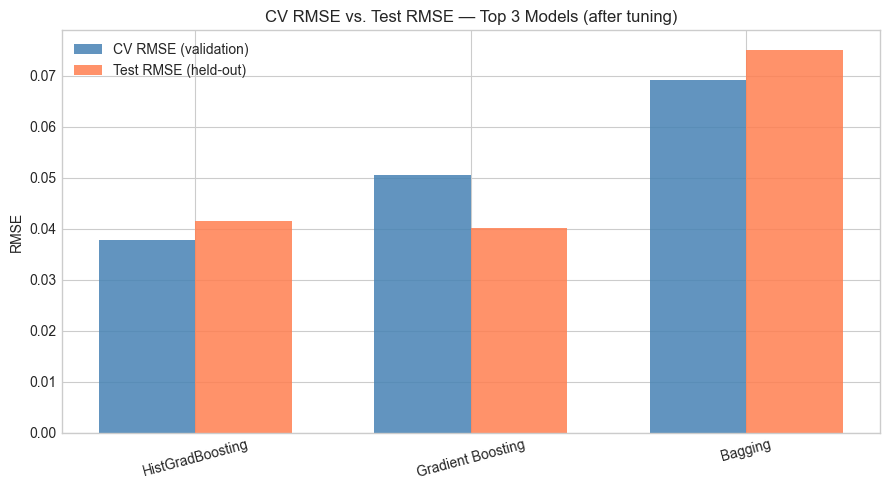

In [40]:
cv_map = dict(zip(results_df["Model"], results_df["CV RMSE (mean)"]))

compare = pd.DataFrame({
    "Model"    : top3_names,
    "CV RMSE"  : [cv_map.get(n, np.nan) for n in top3_names],
    "Test RMSE": [tuned_df[tuned_df["Model"]==n]["Test RMSE"].values[0] for n in top3_names],
})
compare["Gap (Test−CV)"] = compare["Test RMSE"] - compare["CV RMSE"]

print("Generalisation check — CV RMSE vs. Test RMSE (after tuning):")
print(compare.to_string(index=False))
print()
print("A Gap close to 0 means the model generalises well.")

# --- Side-by-side bar chart --------------------------------------------------
x = np.arange(len(compare))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, compare["CV RMSE"],   w, label="CV RMSE (validation)",
       color="steelblue", alpha=0.85)
ax.bar(x + w/2, compare["Test RMSE"], w, label="Test RMSE (held-out)",
       color="coral",     alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(compare["Model"], rotation=15)
ax.set_ylabel("RMSE")
ax.set_title("CV RMSE vs. Test RMSE — Top 3 Models (after tuning)")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Project Summary

In [41]:
print("\n" + "="*60)
print("  PROJECT SUMMARY")
print("="*60)
print(f"  Dataset                  : books.csv (Goodreads)")
print(f"  Raw rows                 : {df_raw.shape[0]:,}")
print(f"  Rows after cleaning      : {df.shape[0]:,}")
print(f"  Rows removed             : {df_raw.shape[0] - df.shape[0]:,}")
print(f"  Numeric features         : {len(num_features)}")
print(f"  Categorical features     : {len(cat_features)}")
print(f"  Total model features     : {len(num_features) + len(cat_features)}")
print(f"  Target variable          : {TARGET_COL}")
print(f"  Models evaluated         : {len(models)} (scikit-learn only)")
print(f"  Best model               : {best_model_name}")
print("─"*60)
print(f"  Test RMSE                : {rmse:.5f}")
print(f"  Test MAE                 : {mae:.5f}")
print(f"  Test MAPE                : {mape:.2f}%")
print(f"  Test R²                  : {r2:.5f}")
print("="*60)


  PROJECT SUMMARY
  Dataset                  : books.csv (Goodreads)
  Raw rows                 : 11,123
  Rows after cleaning      : 11,076
  Rows removed             : 47
  Numeric features         : 16
  Categorical features     : 4
  Total model features     : 20
  Target variable          : average_rating
  Models evaluated         : 14 (scikit-learn only)
  Best model               : Gradient Boosting
────────────────────────────────────────────────────────────
  Test RMSE                : 0.04023
  Test MAE                 : 0.01179
  Test MAPE                : 0.30%
  Test R²                  : 0.97936
